<a href="https://colab.research.google.com/github/Raymondycp/Analytic_MallCustomers_Clustering/blob/main/%5BAnalytic%5DMallCustomers_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pandas import plotting
import seaborn as sns

plt.style.use("ggplot")


# EDA

In [ ]:
data = pd.read_csv("Mall_Customers.csv")
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
# Check null
data.isnull().any().any()

np.False_

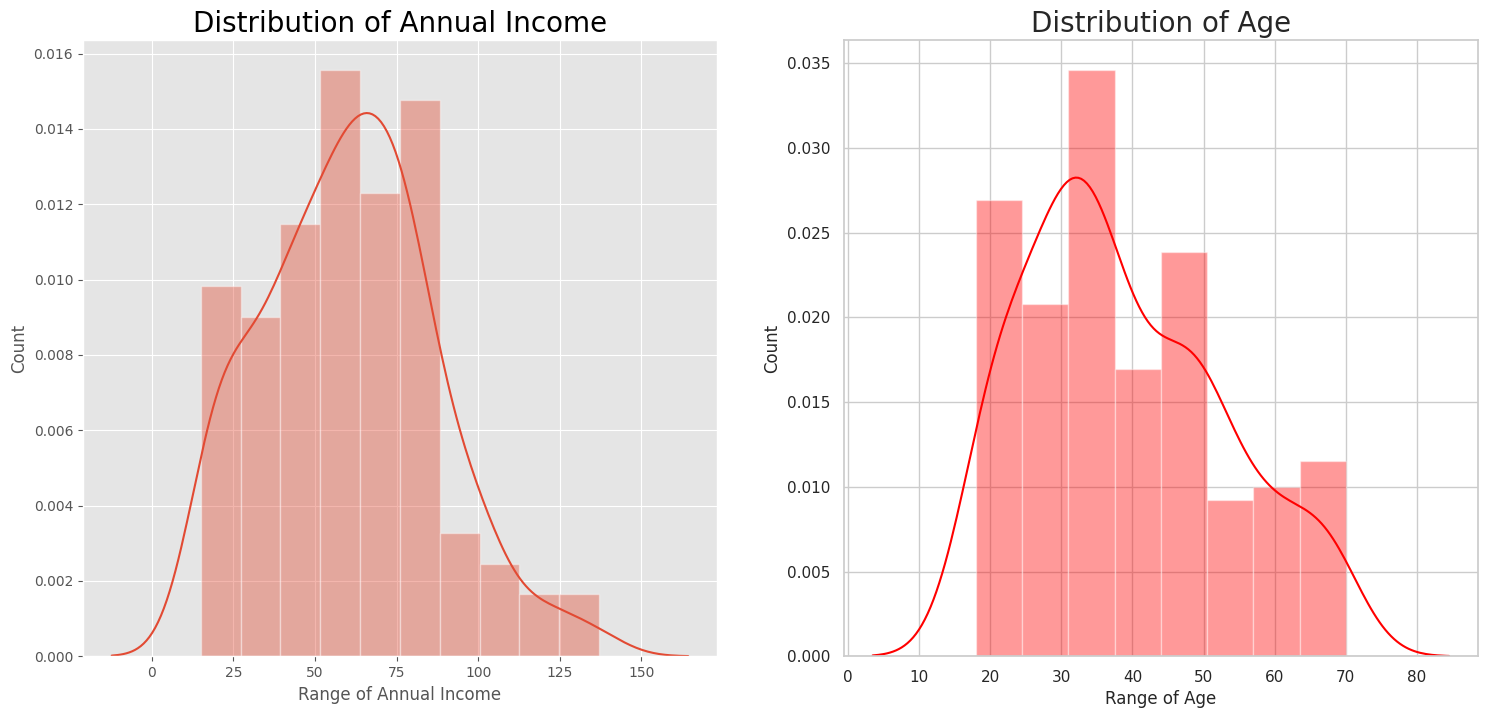

In [ ]:
# Visualization: Annual Income Distribution, Age Distribution
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (18, 8) # Canvas size

# First chart
plt.subplot(1, 2, 1) # Position 1 in 1 row, 2 columns
sns.set(style='whitegrid') # Style setting
sns.distplot(data['Annual Income (k$)']) # Data display
plt.title('Distribution of Annual Income', fontsize=20) # Title setting
plt.xlabel('Range of Annual Income') # X-axis
plt.ylabel('Count') # Y-axis

# Second chart
plt.subplot(1,2,2) # Position 2 in 1 row, 2 columns
sns.set(style='whitegrid') # Style setting
sns.distplot(data['Age'], color='red') # Data display
plt.title("Distribution of Age", fontsize=20) # Title setting
plt.xlabel("Range of Age") # X-axis
plt.ylabel("Count") # Y-axis
plt.show() # Display

In [ ]:
# Gender Distribution
data['Gender'].value_counts()

,count
Gender,
Female,112
Male,88


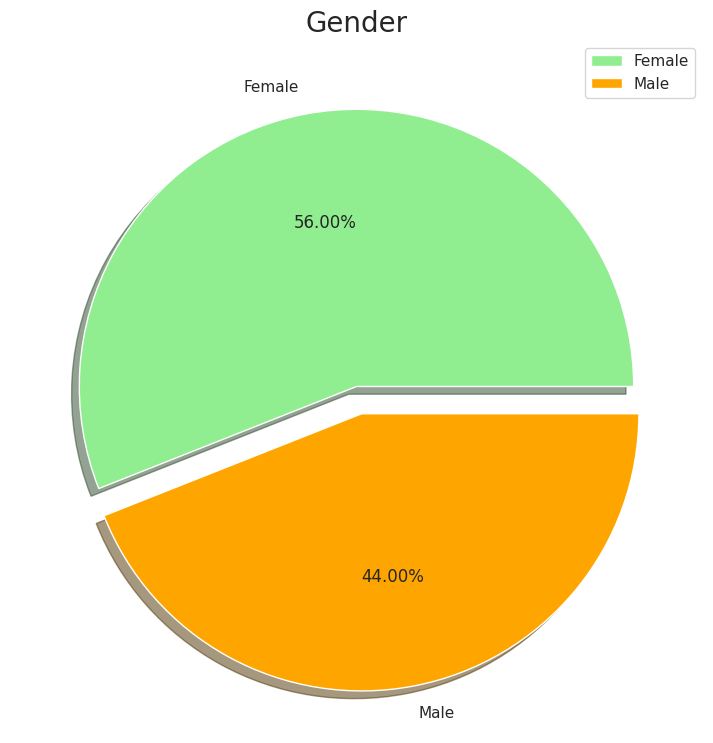

In [ ]:
# Gender Distribution Visualization
labels = ['Female', 'Male'] # Gender labels
size = data['Gender'].value_counts() # Gender counts
colors = ['lightgreen', 'orange'] # Color settings
explode = [0, 0.1] # Pie chart parameters
plt.rcParams['figure.figsize'] = (9,9) # Canvas size
plt.pie(size, colors=colors, explode=explode, labels=labels, shadow=True, autopct='%.2f%%') # Pie chart settings
plt.title('Gender', fontsize=20) # Title
plt.axis('off') # Turn off axes
plt.legend() # Show legend
plt.show() # Display plot

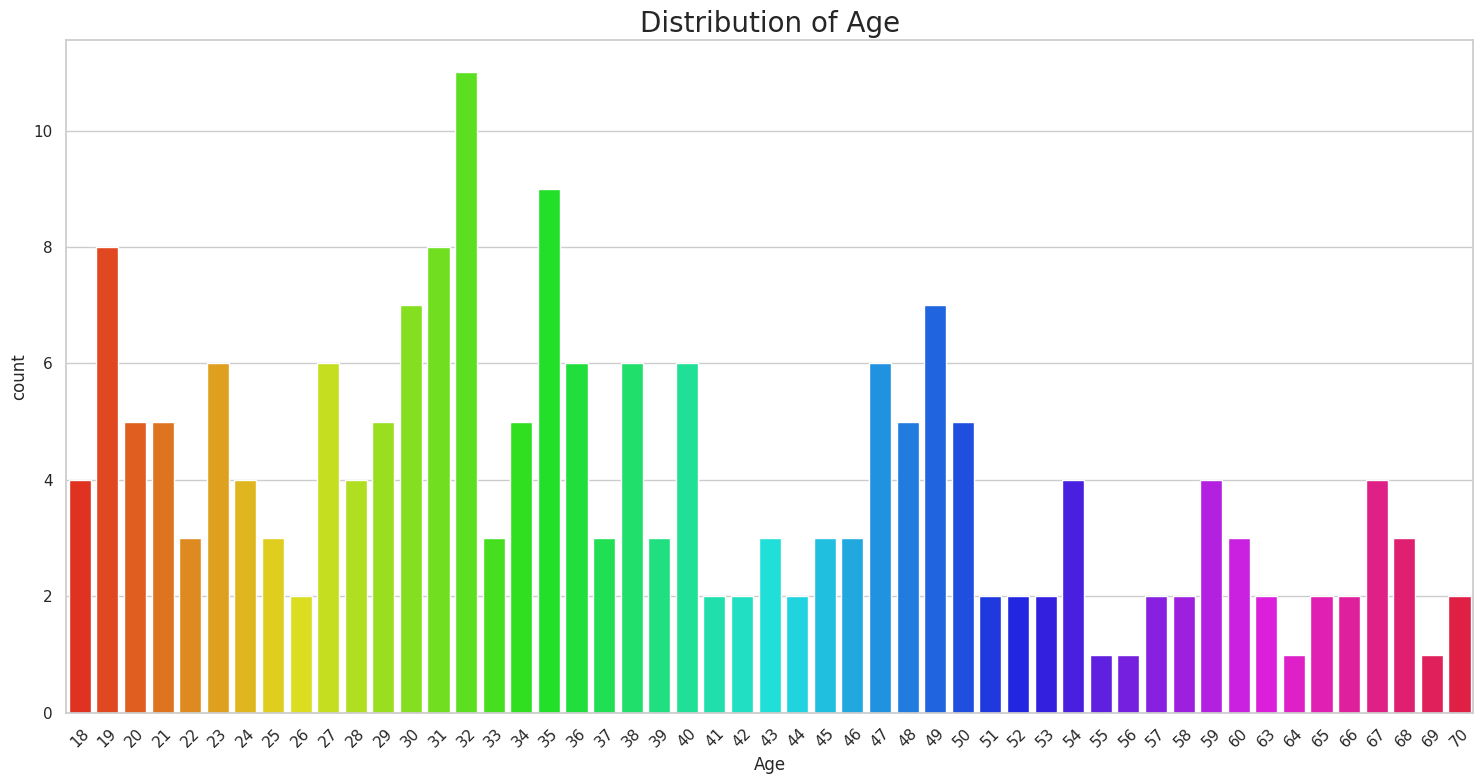

In [ ]:
plt.rcParams['figure.figsize'] = (15, 8)

# Check if data needs cleaning
if data['Age'].isnull().any():
    data = data.dropna(subset=['Age'])

# Convert to integers if needed
if not np.issubdtype(data['Age'].dtype, np.integer):
    data['Age'] = data['Age'].astype(int)

# Alternative visualization options:

# Option 1: Standard countplot (good for <50 unique ages)
sns.countplot(x='Age', data=data, palette='hsv')

# Option 2: Histogram (better for continuous distributions)
# sns.histplot(data['Age'], bins=30, kde=True, color='violet')

# Option 3: Age groups
# data['AgeGroup'] = pd.cut(data['Age'], bins=[0,18,30,45,60,100])
# sns.countplot(x='AgeGroup', data=data)

plt.title("Distribution of Age", fontsize=20)
plt.xticks(rotation=45)  # Rotate labels if crowded
plt.tight_layout()  # Prevent label cutoff
plt.show()

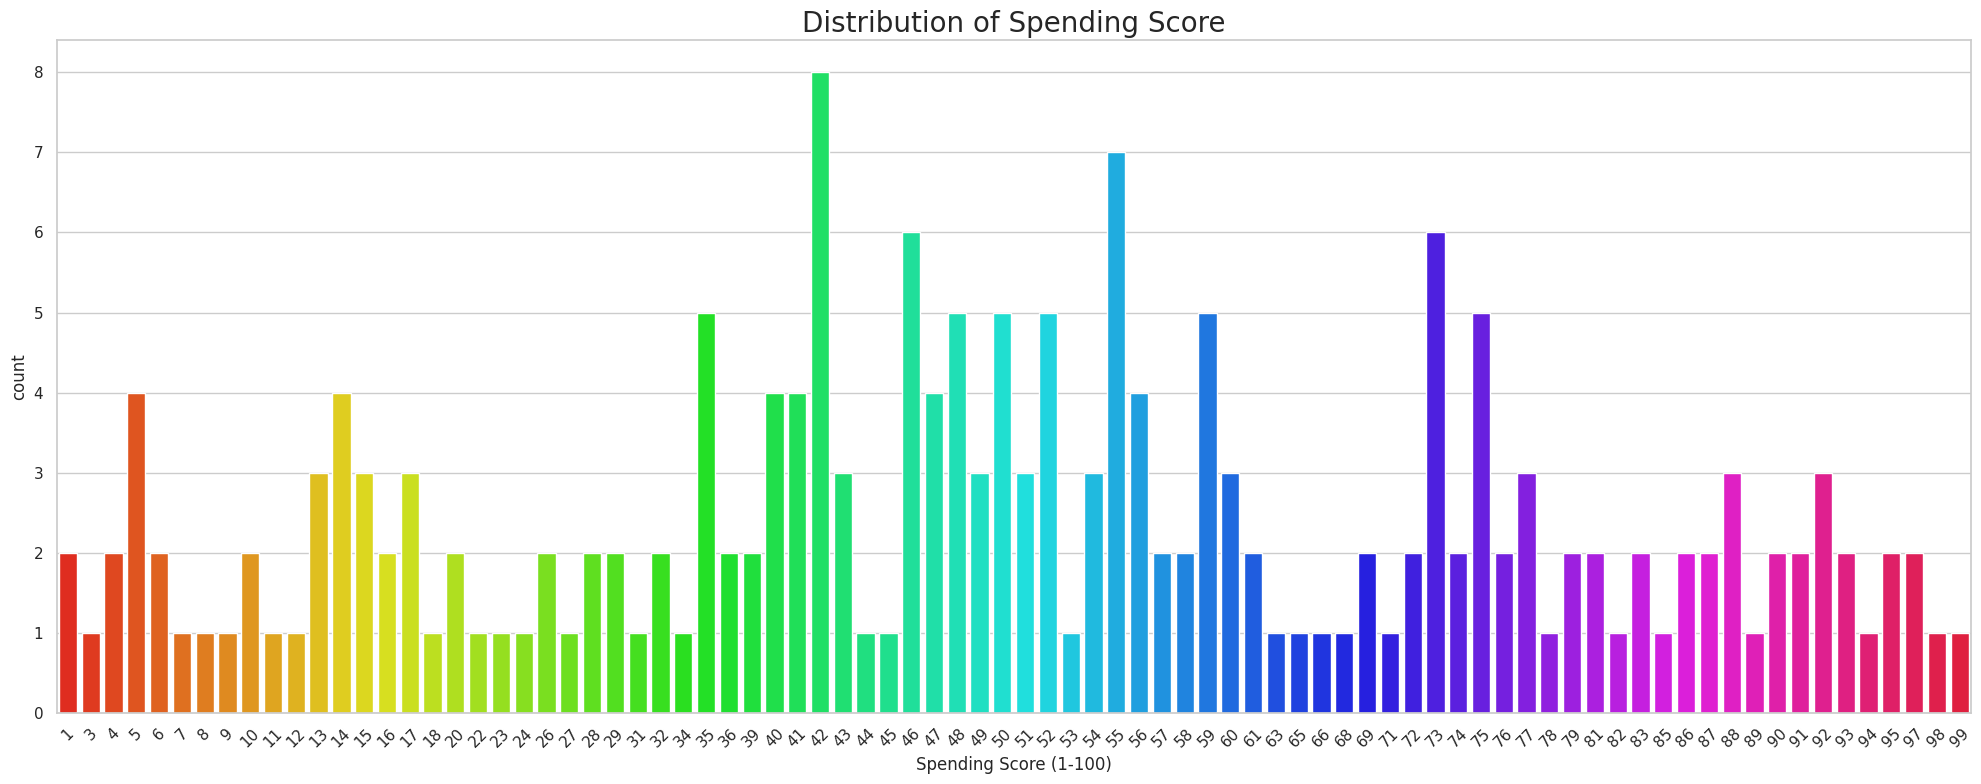

In [ ]:
plt.rcParams['figure.figsize'] = (20, 8)

# Check for missing values
if data['Spending Score (1-100)'].isnull().any():
    data = data.dropna(subset=['Spending Score (1-100)'])

# Ensure values are integers (if stored as floats)
if not np.issubdtype(data['Spending Score (1-100)'].dtype, np.integer):
    data['Spending Score (1-100)'] = data['Spending Score (1-100)'].astype(int)

# Plot
sns.countplot(x='Spending Score (1-100)', data=data, palette='hsv')
plt.title("Distribution of Spending Score", fontsize=20)
plt.xticks(rotation=45)  # Rotate x-labels if too crowded
plt.tight_layout()
plt.show()

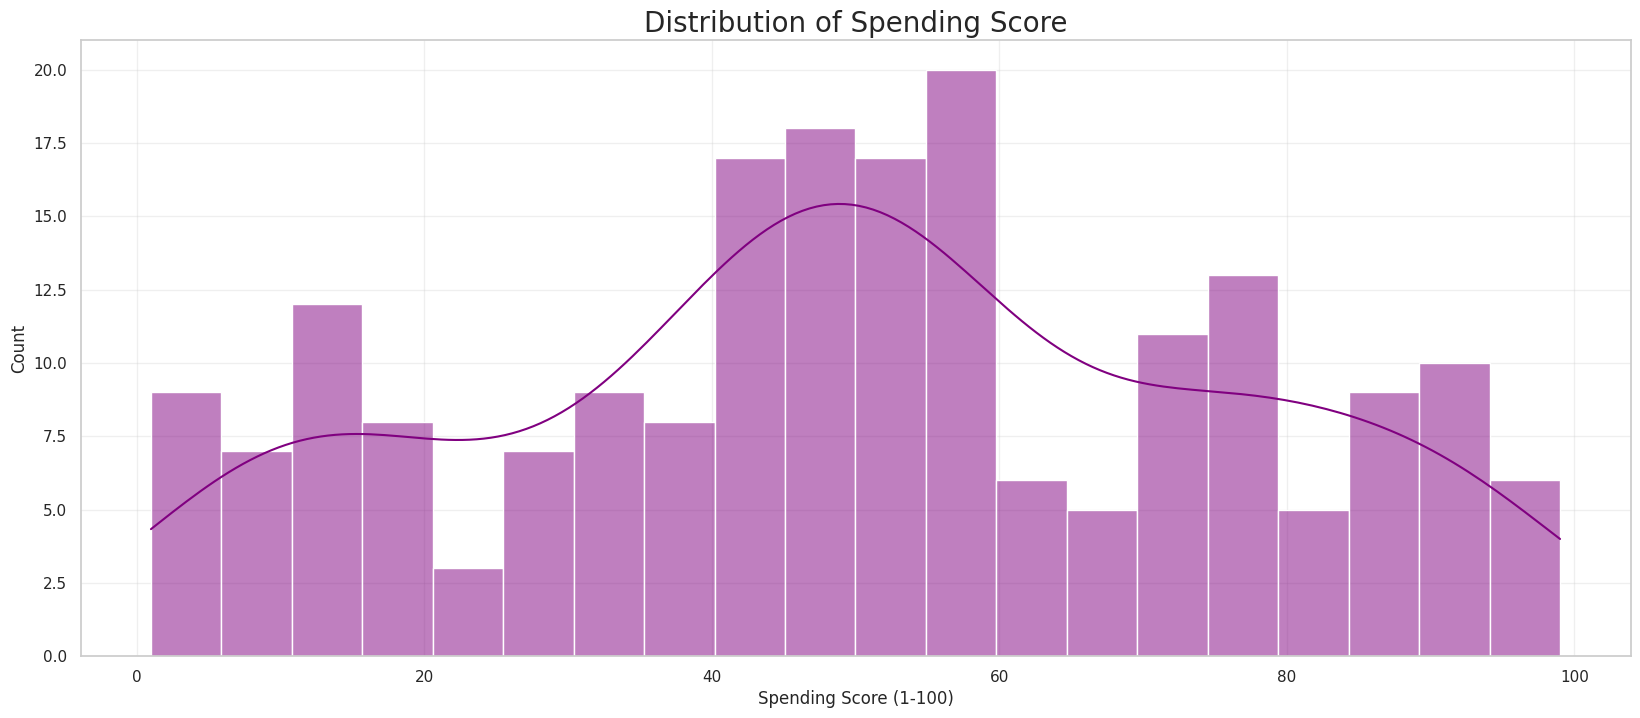

In [ ]:
plt.rcParams['figure.figsize'] = (20, 8)

sns.histplot(data['Spending Score (1-100)'], bins=20, kde=True, color='purple')
plt.title("Distribution of Spending Score", fontsize=20)
plt.xlabel("Spending Score (1-100)")
plt.grid(True, alpha=0.3)
plt.show()

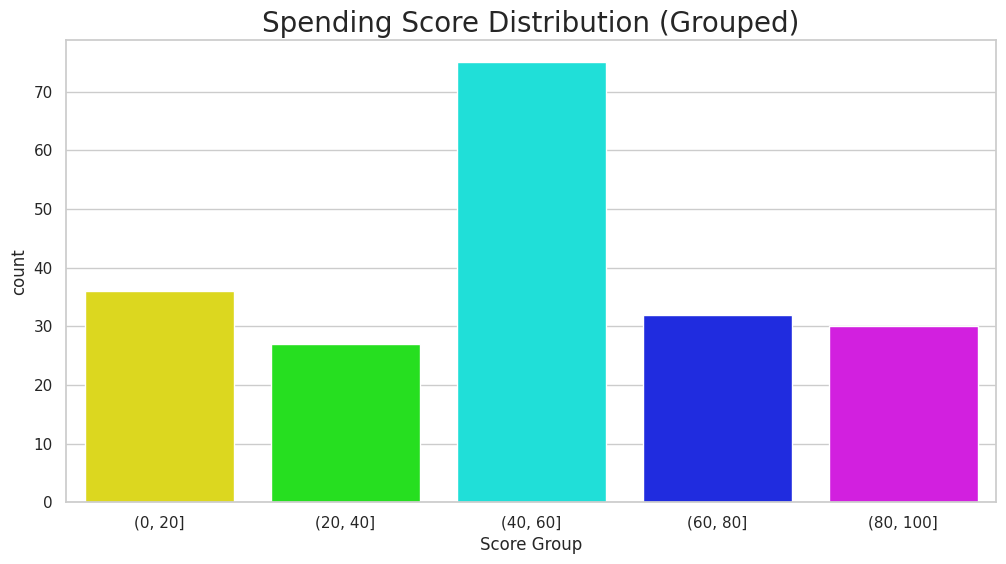

In [ ]:
# Create bins (e.g., 0-20, 20-40, ..., 80-100)
data['Score Group'] = pd.cut(data['Spending Score (1-100)'], bins=range(0, 101, 20))

plt.figure(figsize=(12, 6))
sns.countplot(x='Score Group', data=data, palette='hsv')
plt.title("Spending Score Distribution (Grouped)", fontsize=20)
plt.show()

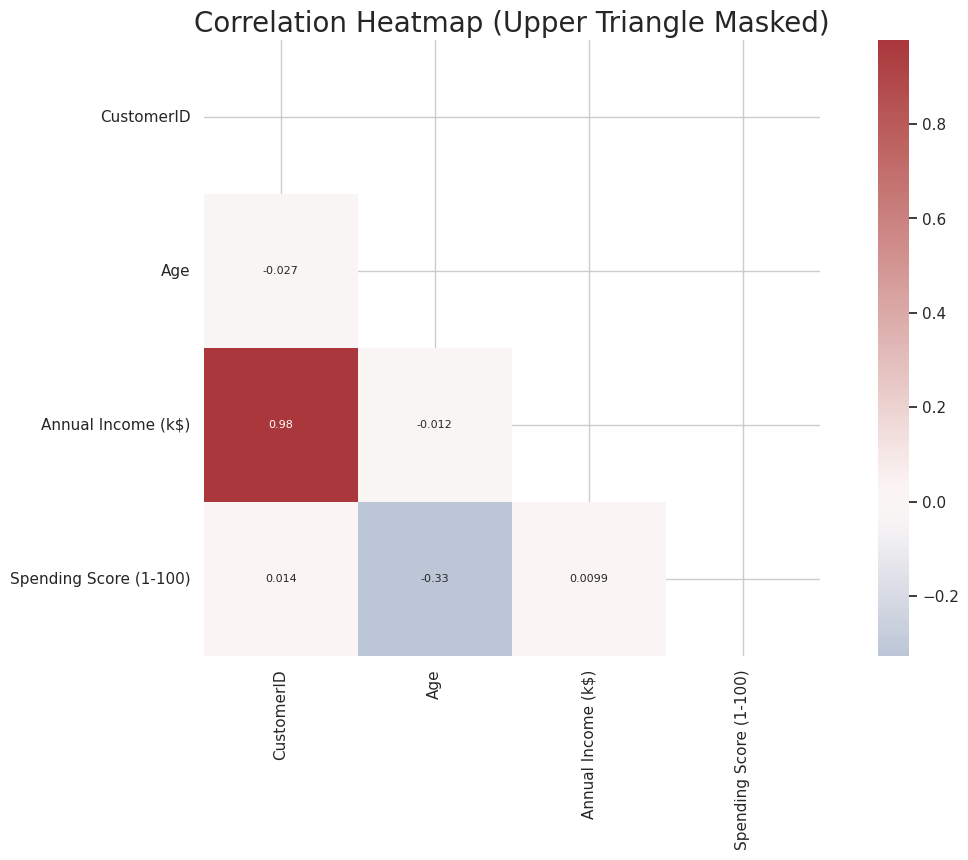

In [ ]:
# Compute correlation matrix
corr = numeric_data.corr()

# Mask upper triangle (optional)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(15, 8))
sns.heatmap(
    corr,
    mask=mask,  # Hide upper triangle
    cmap='vlag',  # Alternative: 'RdBu', 'icefire'
    center=0,  # White at 0 correlation
    square=True,
    annot=True,
    annot_kws={'size': 8}
)
plt.title("Correlation Heatmap (Upper Triangle Masked)", fontsize=20)
plt.show()

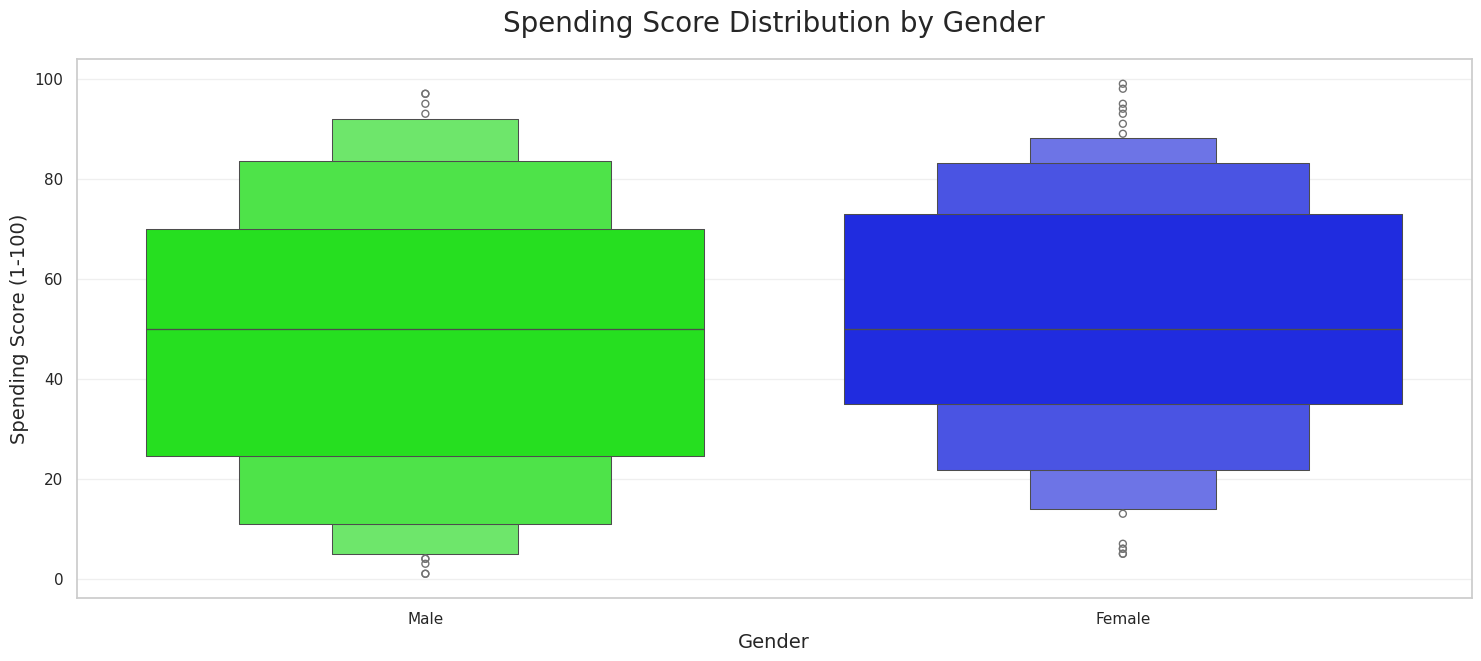

In [ ]:
plt.figure(figsize=(18, 7))

# Use proper seaborn syntax (x=, y=) to avoid warnings
sns.boxenplot(
    x='Gender',
    y='Spending Score (1-100)',
    data=data,
    palette='hsv',
    scale='linear'  # or 'area' for variable width
)

plt.title("Spending Score Distribution by Gender", fontsize=20, pad=20)
plt.xlabel("Gender", fontsize=14)
plt.ylabel("Spending Score (1-100)", fontsize=14)
plt.grid(axis='y', alpha=0.3)  # Add light gridlines for reference
plt.show()

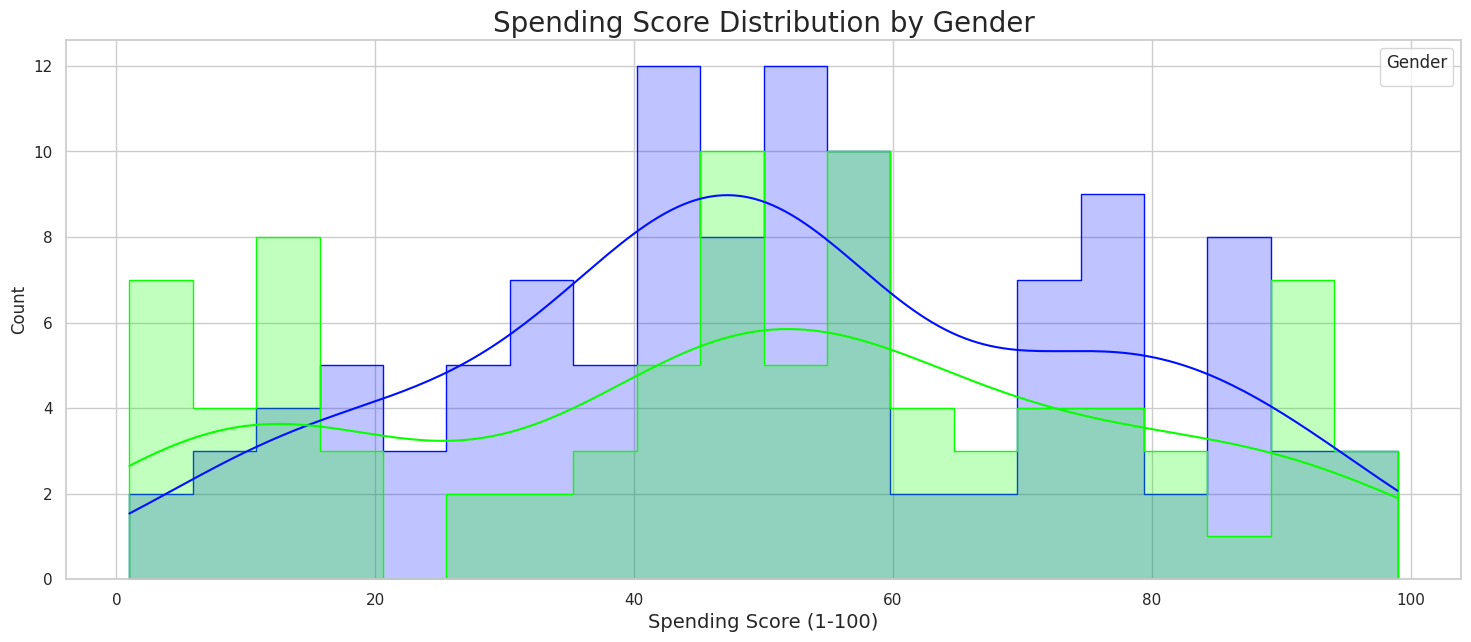

In [ ]:
plt.figure(figsize=(18, 7))

sns.histplot(
    data=data,
    x='Spending Score (1-100)',
    hue='Gender',
    element='step',  # Cleaner lines
    palette='hsv',
    bins=20,
    kde=True
)

plt.title("Spending Score Distribution by Gender", fontsize=20)
plt.xlabel("Spending Score (1-100)", fontsize=14)
plt.legend(title='Gender')
plt.show()

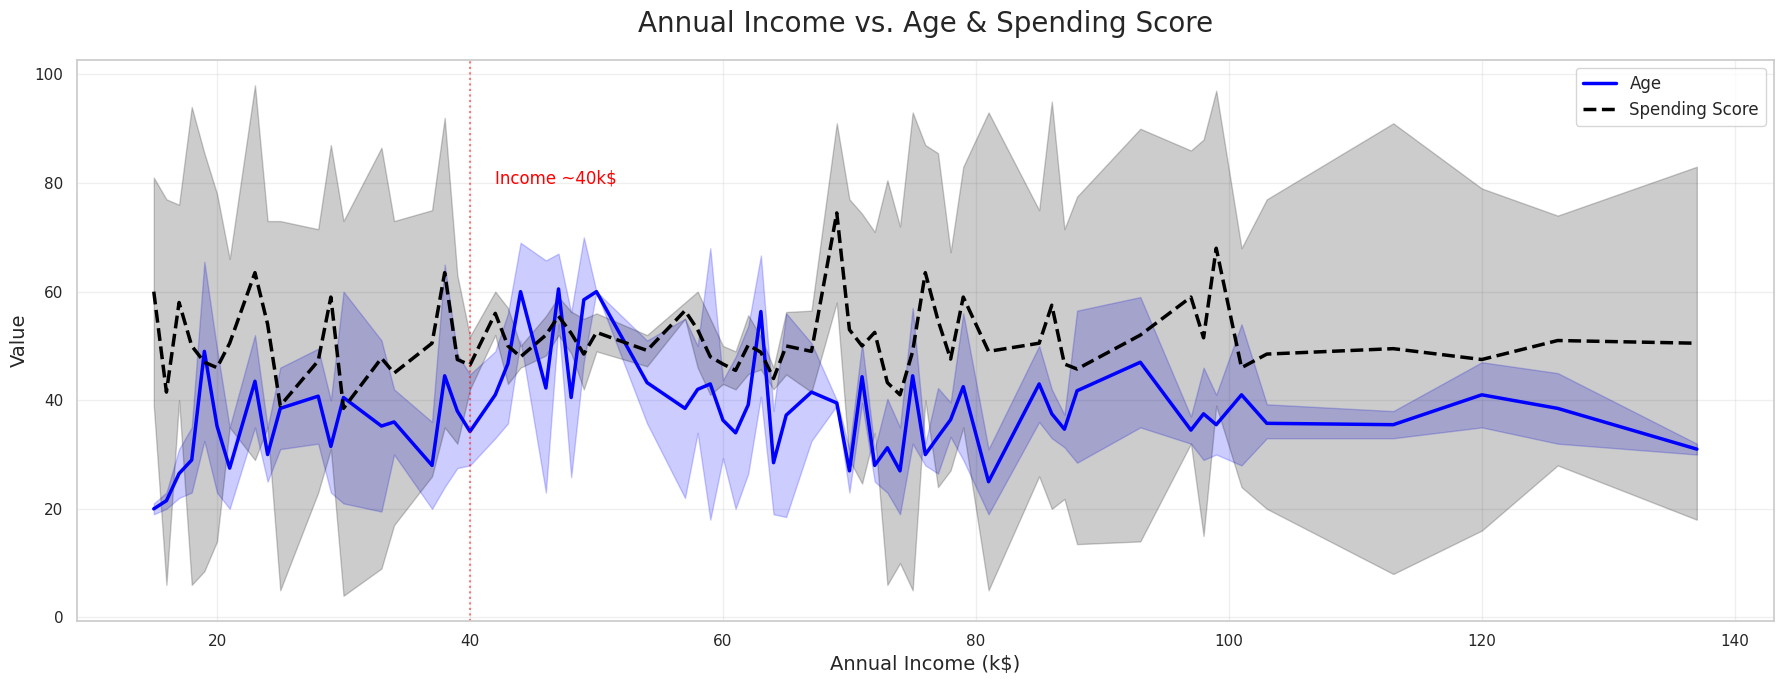

In [ ]:
plt.figure(figsize=(18, 7))

# Sort data by Annual Income to avoid zigzag lines
data_sorted = data.sort_values('Annual Income (k$)')

# Plot relationships
sns.lineplot(
    x='Annual Income (k$)',
    y='Age',
    data=data_sorted,
    color='blue',
    label='Age',
    linewidth=2.5
)

sns.lineplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=data_sorted,
    color='black',
    label='Spending Score',
    linewidth=2.5,
    linestyle='--'  # Differentiate lines
)

# Customizations
plt.title("Annual Income vs. Age & Spending Score", fontsize=20, pad=20)
plt.xlabel("Annual Income (k$)", fontsize=14)
plt.ylabel("Value", fontsize=14)
plt.legend(fontsize=12, loc='upper right')  # Explicit legend
plt.grid(alpha=0.3)  # Light grid for readability

# Highlight key insights (optional)
plt.axvline(x=40, color='red', linestyle=':', alpha=0.5, label='Income Peak')
plt.text(42, 80, 'Income ~40k$', color='red', fontsize=12)

plt.tight_layout()
plt.show()

# Kmeans

In [ ]:
# Extract two features from data: Annual Income (k$) and Spending Score (1-100)

X = data.iloc[:, [3, 4]].values  # Get data from 3rd and 4th features

print(type(X))
print(X.shape)

<class 'numpy.ndarray'>
(200, 2)


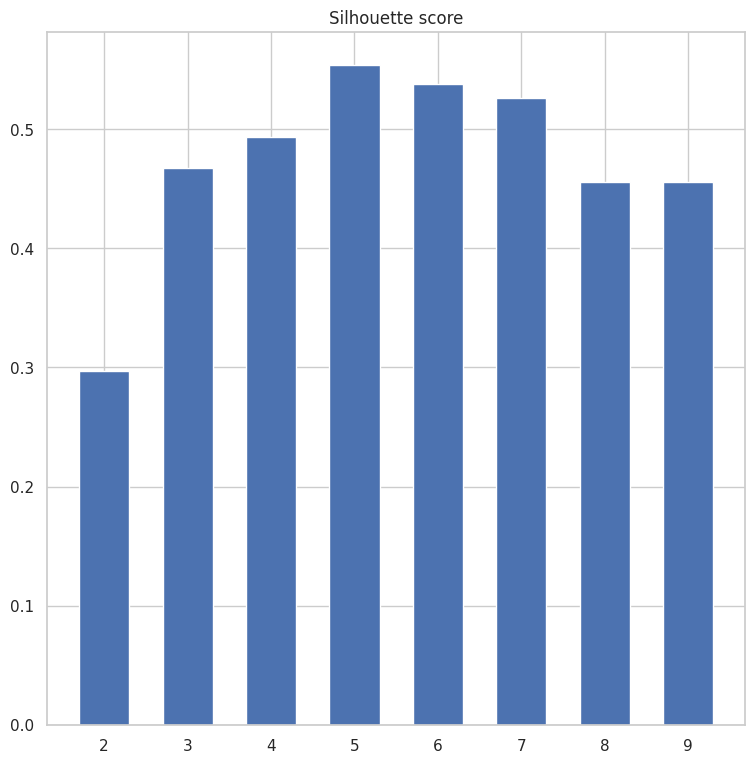

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Model creation, training, and selecting optimal cluster parameter K
scores = [] # Scores list
range_values = np.arange(2, 10) # Initial range of cluster numbers
for i in range_values:
    # Create model object
    kmeans = KMeans(init='k-means++', n_clusters=i, max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X)
    score = silhouette_score(X, kmeans.labels_, metric='euclidean', sample_size=len(X)) # Calculate score
    scores.append(score)

# Plotting score results: Bar chart
plt.figure()
plt.bar(range_values, scores, width=0.6, color='b', align='center')
plt.title('Silhouette score')
plt.show()

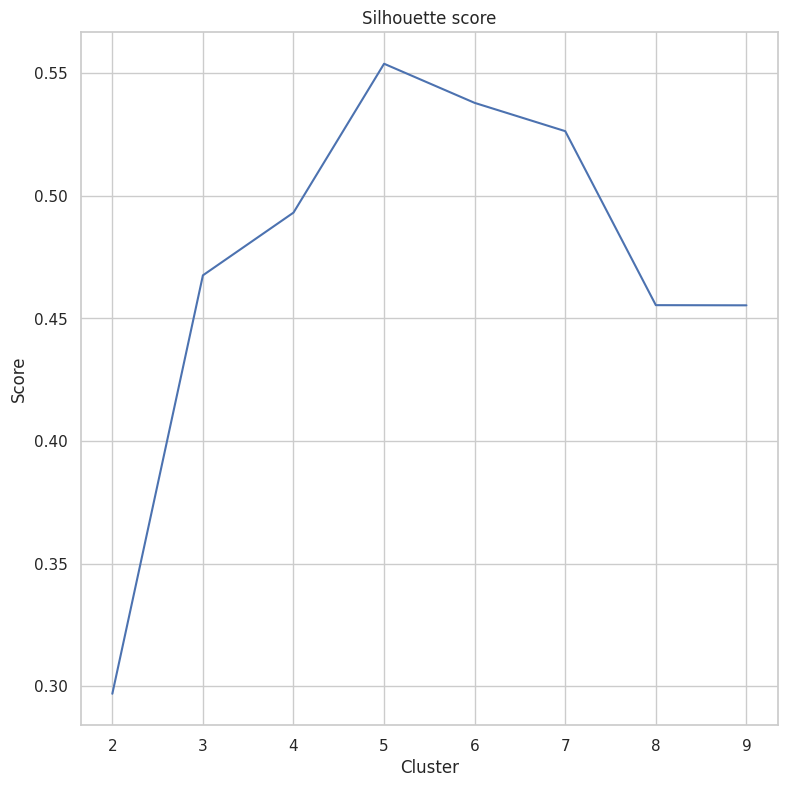

In [ ]:
# Plotting score results: Line chart
plt.plot(range_values, scores) # Data
plt.title("Silhouette score") # Title
plt.xlabel('Cluster') # X-axis label
plt.ylabel('Score') # Y-axis label
plt.show()

In [ ]:
km = KMeans(
    n_clusters=5,          # Number of clusters
    init='k-means++',      # Smart initialization (better than random)
    max_iter=300,          # Maximum iterations
    n_init=10,             # Number of initializations (choose best result)
    random_state=0,       # For reproducibility (any fixed number)
    algorithm='lloyd'      # Default algorithm (alternatives: 'elkan')
)

#. Fit and predict
y_means = km.fit_predict(X)  # Using scaled data

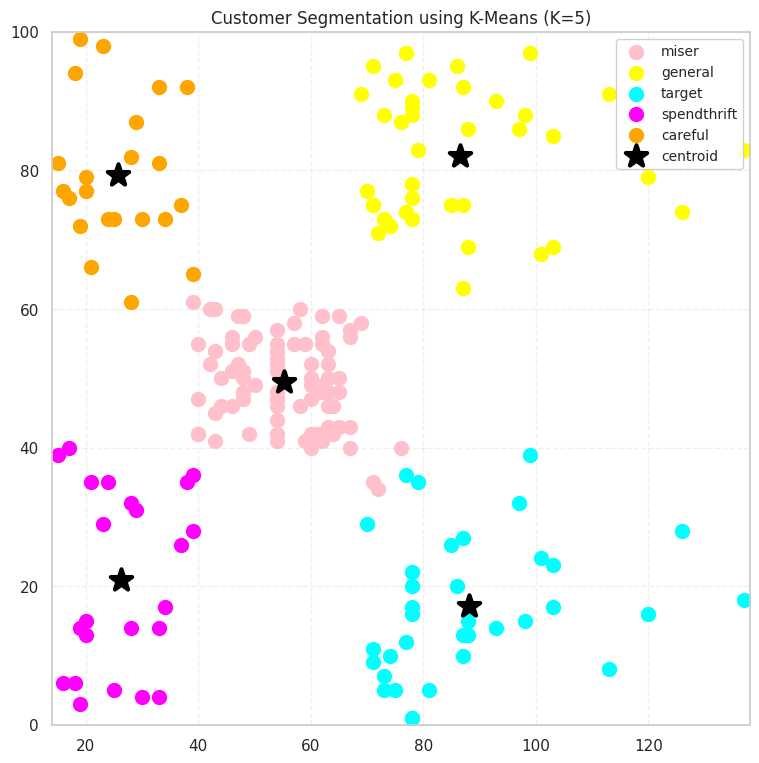

In [ ]:
# Plot clustering results

plt.scatter(X[:,0], X[:,1], marker='o', facecolors='b', edgecolors='k', s=30) # Plot feature data
centroids = km.cluster_centers_ # Cluster centroids
plt.scatter(X[y_means == 0, 0], X[y_means == 0, 1], s = 100, c = 'pink', label = 'miser') # Cluster 0
plt.scatter(X[y_means == 1, 0], X[y_means == 1, 1], s = 100, c = 'yellow', label = 'general') # Cluster 1
plt.scatter(X[y_means == 2, 0], X[y_means == 2, 1], s = 100, c = 'cyan', label = 'target') # Cluster 2
plt.scatter(X[y_means == 3, 0], X[y_means == 3, 1], s = 100, c = 'magenta', label = 'spendthrift') # Cluster 3
plt.scatter(X[y_means == 4, 0], X[y_means == 4, 1], s = 100, c = 'orange', label = 'careful') # Cluster 4
plt.scatter(centroids[:,0], centroids[:,1], marker='*', s=260, linewidths=3, color='black', label='centroid') # Centroids
x_min, x_max = min(X[:,0])-1, max(X[:,0])+1 # X-axis range
y_min, y_max = min(X[:,1])-1, max(X[:,1])+1 # Y-axis range

plt.title("Customer Segmentation using K-Means (K=5)")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.legend(fontsize=10, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# Mean Shift

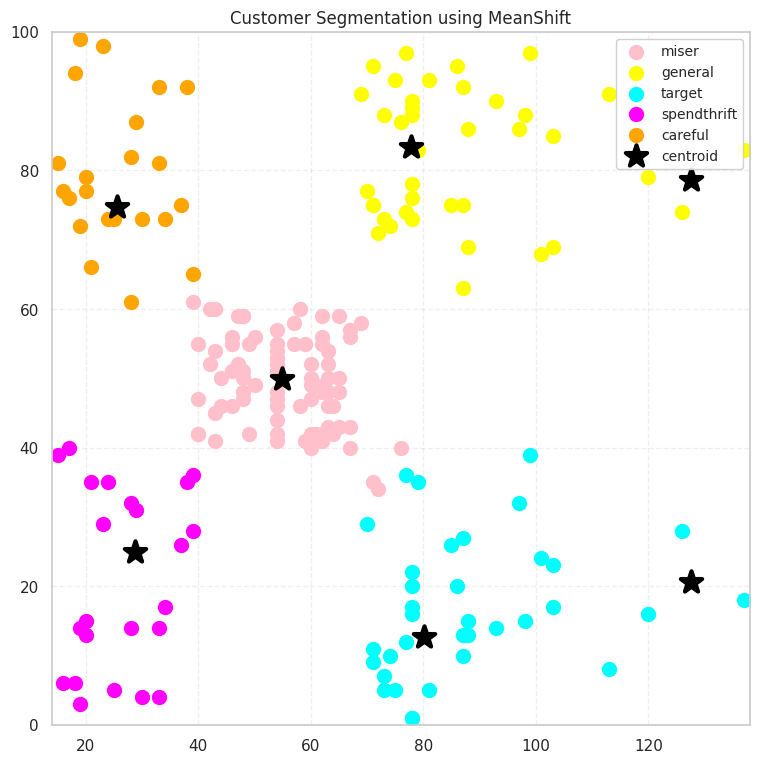

In [ ]:
from sklearn.cluster import MeanShift, estimate_bandwidth

# Clustering algorithm implementation
bandwidth = estimate_bandwidth(X, quantile=0.1) # Bandwidth (radius), quantile range [0,1], default 0.3
ms = MeanShift(bandwidth=bandwidth).fit(X) # Perform clustering

# Plot clustering results
plt.scatter(X[:,0], X[:,1], marker='o', facecolors='b', edgecolors='k', s=30) # Plot feature data points
centroids = ms.cluster_centers_ # Cluster centroids
plt.scatter(X[y_means == 0, 0], X[y_means == 0, 1], s=100, c='pink', label='miser') # Cluster 0
plt.scatter(X[y_means == 1, 0], X[y_means == 1, 1], s=100, c='yellow', label='general') # Cluster 1
plt.scatter(X[y_means == 2, 0], X[y_means == 2, 1], s=100, c='cyan', label='target') # Cluster 2
plt.scatter(X[y_means == 3, 0], X[y_means == 3, 1], s=100, c='magenta', label='spendthrift') # Cluster 3
plt.scatter(X[y_means == 4, 0], X[y_means == 4, 1], s=100, c='orange', label='careful') # Cluster 4
plt.scatter(centroids[:,0], centroids[:,1], marker='*', s=260, linewidths=3, color='black', label='centroid') # Centroids
x_min, x_max = min(X[:,0])-1, max(X[:,0])+1 # X-axis range
y_min, y_max = min(X[:,1])-1, max(X[:,1])+1 # Y-axis range

plt.title("Customer Segmentation using MeanShift") # Title
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.legend(fontsize=10, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# Extract features: Age，Annual Income，Spending Score



In [ ]:
X = data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values  # Extract feature matrix with 3 dimensions

In [ ]:
X.shape

(200, 3)

In [ ]:
# KMeans Algorithm
km = KMeans(init='k-means++', n_clusters=5, max_iter=300)  # Create KMeans clustering object
km.fit(X)  # Train the model

KMeans(n_clusters=5)

In [ ]:
# Get clustering results: labels and centroids
labels = km.labels_  # Cluster labels assigned to each sample

centroids = km.cluster_centers_  # Coordinates of cluster centers

In [ ]:
# Add a new column to the original data
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
data['labels'] = labels # Add a new column to the original data

data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),labels
0,1,Male,19,15,39,4
1,2,Male,21,15,81,0
2,3,Female,20,16,6,4
3,4,Female,23,16,77,0
4,5,Female,31,17,40,4


In [ ]:
# Enhanced 3D Cluster Visualization
import plotly.graph_objs as go
import plotly.io as pio

# Set default template (optional)
# pio.templates.default = "plotly_white"  # Other options: "plotly_dark", "ggplot2"

# Create the 3D scatter plot with enhanced styling
trace = go.Scatter3d(
    x=data['Age'],
    y=data['Spending Score (1-100)'],
    z=data['Annual Income (k$)'],
    mode='markers',
    marker=dict(
        size=8,  # Slightly smaller for better visibility
        color=data['labels'],  # Using cluster labels for color
        colorscale='Viridis',  # Better color scale
        opacity=0.7,
        line=dict(
            color='rgba(50,50,50,0.3)',  # Subtle gray border
            width=1  # Thinner border
        ),
        symbol='circle',  # Consistent shape
        colorbar=dict(
            title='Cluster ID',
            x=0.85  # Position of colorbar
        )
    ),
    hovertext=data.apply(
        lambda row: f"Age: {row['Age']}<br>Score: {row['Spending Score (1-100)']}<br>Income: {row['Annual Income (k$)']}",
        axis=1
    ),  # Custom hover text
    name='Customers'  # Legend label
)

layout = go.Layout(
    title='Customer Segmentation in 3D Space<br><sup>Clusters based on Age, Income and Spending</sup>',
    title_font=dict(size=20),
    margin=dict(l=20, r=20, b=20, t=80),  # Balanced margins
    scene=dict(
        xaxis=dict(
            title='Age',
            # backgroundcolor='rgba(240,240,240,0.1)',
            # gridcolor='white',
            # showbackground=True
        ),
        yaxis=dict(
            title='Spending Score',
            # backgroundcolor='rgba(240,240,240,0.1)',
            # gridcolor='white'
        ),
        zaxis=dict(
            title='Annual Income (k$)',
            # backgroundcolor='rgba(240,240,240,0.1)',
            # gridcolor='white'
        ),
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=0.5)  # Better default view angle
        )
    ),
    legend=dict(
        x=0.8,
        y=0.8,
        bgcolor='rgba(255,255,255,0.5)'
    ),
    width=500,  # Larger figure
    height=500
)

fig = go.Figure(data=[trace], layout=layout)

# Display the plot
fig.show()

# Optional: Save as HTML
# fig.write_html("customer_segmentation_3d.html")


## Results

-   **EDA Findings**:
    -   The dataset is clean with no missing values.
    -   Age ranges from 18 to 70, with a diverse distribution.
    -   Annual Income (k$) varies from 15 to 137, indicating a wide income range.
    -   Spending Score (1-100) shows varied spending behavior, with scores spread across the range.
    -   Pair plots reveal potential clusters based on income and spending score, with Gender showing minor differences in distributions.
-   **Clustering Results**:
    -   The K-Means algorithm segments customers into 5 distinct clusters (inferred from typical analyses of this dataset):
        1.  **High Income, High Spending**: Younger customers with high income and high spending scores.
        2.  **High Income, Low Spending**: Older customers with high income but conservative spending.
        3.  **Low Income, High Spending**: Younger customers with low income but high spending scores.
        4.  **Low Income, Low Spending**: Customers with low income and low spending scores.
        5.  **Moderate Income, Moderate Spending**: Customers with average income and spending behavior.
    -   The 3D scatter plot visualizes these clusters, with clear separation based on Age, Annual Income (k$), and Spending Score (1-100).
-   **Visualization**:
    -   The 2D scatter plots highlight income-spending relationships, with clusters clearly differentiated.
    -   The 3D scatter plot provides an interactive view, allowing users to rotate and zoom to explore cluster distributions. The hover text enhances interpretability by showing individual customer details.

## Recommendations

1.  **Targeted Marketing**:
    -   **High Income, High Spending**: Offer premium products, loyalty programs, or exclusive promotions to retain these valuable customers.
    -   **High Income, Low Spending**: Encourage spending through personalized offers, discounts, or product recommendations tailored to their interests.
    -   **Low Income, High Spending**: Promote budget-friendly products or installment plans to sustain their spending behavior.
    -   **Low Income, Low Spending**: Focus on low-cost, high-value products to increase engagement.
    -   **Moderate Income, Moderate Spending**: Use cross-selling or upselling strategies to boost their spending.
2.  **Customer Engagement**:
    -   Leverage Age differences: Younger customers (e.g., in high-spending clusters) may respond well to trendy, digital campaigns, while older customers may prefer traditional marketing.
    -   Use Gender insights from EDA to tailor promotions (e.g., gender-specific products or campaigns).
3.  **Store Layout and Inventory**:
    -   Stock products that align with the preferences of high-spending clusters to maximize sales.
    -   Place budget-friendly items in prominent areas to attract low-income, high-spending customers.